# Đồ án Khai thác Dữ liệu - Dự đoán Giá Nhà Việt Nam

Notebook này thực hiện toàn bộ pipeline từ tải dữ liệu, tiền xử lý, huấn luyện model đến đánh giá kết quả.



In [1]:
   import sys
   print(sys.executable)

D:\ML_house_price\venv\Scripts\python.exe


In [3]:
import pandas as pd
import numpy as np
from pathlib import Path
import sys
import os

project_root = Path.cwd()
if (project_root / 'src').exists():
    project_root = project_root
elif (project_root.parent / 'src').exists():
    project_root = project_root.parent
else:
    project_root = Path(__file__).parent.parent if '__file__' in globals() else Path.cwd()

os.chdir(project_root)
sys.path.append(str(project_root / 'src'))

from utils.descriptive_stats import generate_descriptive_stats
from preprocess.preprocess import DataPreprocessor
from models.train_xgboost import train_xgboost, save_model
from models.predict_xgboost import load_latest_model
from evaluation.evaluate import (
    calculate_regression_metrics,
    plot_predictions,
    plot_residuals,
    plot_feature_importance,
    save_evaluation_report
)

print(f"Project root: {project_root}")
print(f"Working directory: {os.getcwd()}")



Project root: D:\ML_house_price
Working directory: D:\ML_house_price


## 1. Tải và kiểm tra dữ liệu

Dataset: Vietnam Housing Dataset 2024 từ Kaggle



In [5]:
data_path = project_root / 'data' / 'raw'
csv_files = list(data_path.glob('*.csv'))

if not csv_files:
    raise FileNotFoundError(f"Không tìm thấy file CSV trong {data_path}. Vui lòng tải dataset từ Kaggle.")

df = pd.read_csv(csv_files[0])
print(f"Kích thước dữ liệu: {df.shape}")
print(f"\nCác cột: {df.columns.tolist()}")
print(f"\nThông tin dữ liệu:")
print(df.info())
print(f"\nMissing values:")
print(df.isnull().sum())
print(f"\nUnique values per column:")
for col in df.columns:
    print(f"{col}: {df[col].nunique()}")
print(f"\n5 dòng đầu:")
df.head()



Kích thước dữ liệu: (30229, 12)

Các cột: ['Address', 'Area', 'Frontage', 'Access Road', 'House direction', 'Balcony direction', 'Floors', 'Bedrooms', 'Bathrooms', 'Legal status', 'Furniture state', 'Price']

Thông tin dữ liệu:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30229 entries, 0 to 30228
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Address            30229 non-null  object 
 1   Area               30229 non-null  float64
 2   Frontage           18665 non-null  float64
 3   Access Road        16932 non-null  float64
 4   House direction    8990 non-null   object 
 5   Balcony direction  5246 non-null   object 
 6   Floors             26626 non-null  float64
 7   Bedrooms           25067 non-null  float64
 8   Bathrooms          23155 non-null  float64
 9   Legal status       25723 non-null  object 
 10  Furniture state    16110 non-null  object 
 11  Price              30229 non-null 

,Address,Area,Frontage,Access Road,House direction,Balcony direction,Floors,Bedrooms,Bathrooms,Legal status,Furniture state,Price
0,"Dự án The Empire - Vinhomes Ocean Park 2, Xã L...",84.0,NaN,NaN,NaN,NaN,4.0,NaN,NaN,Have certificate,NaN,8.60
1,"Dự án The Crown - Vinhomes Ocean Park 3, Xã Ng...",60.0,NaN,NaN,NaN,NaN,5.0,NaN,NaN,NaN,NaN,7.50
2,"Dự án The Crown - Vinhomes Ocean Park 3, Xã Ng...",90.0,6.0,13.0,Đông - Bắc,Đông - Bắc,5.0,NaN,NaN,Sale contract,NaN,8.90
3,"Đường Nguyễn Văn Khối, Phường 11, Gò Vấp, Hồ C...",54.0,NaN,3.5,Tây - Nam,Tây - Nam,2.0,2.0,3.0,Have certificate,Full,5.35
4,"Đường Quang Trung, Phường 8, Gò Vấp, Hồ Chí Minh",92.0,NaN,NaN,Đông - Nam,Đông - Nam,2.0,4.0,4.0,Have certificate,Full,6.90


## 2. Thống kê mô tả



In [6]:
if len(df) >= 500 and len(df.columns) >= 5:
    stats_df = generate_descriptive_stats(df, output_dir=str(project_root / 'report'))
    print("Đã tạo thống kê mô tả")
    print(stats_df)
else:
    print(f"Cảnh báo: Dataset không đủ yêu cầu (cần >= 500 dòng và >= 5 cột)")
    print(f"Hiện tại: {len(df)} dòng, {len(df.columns)} cột")



Đã tạo thống kê mô tả
               Column     Type  Unique_Count  \
0             Address   object       10265.0   
1                Area  float64           NaN   
2            Frontage  float64           NaN   
3         Access Road  float64           NaN   
4     House direction   object           8.0   
5   Balcony direction   object           8.0   
6              Floors  float64           NaN   
7            Bedrooms  float64           NaN   
8           Bathrooms  float64           NaN   
9        Legal status   object           2.0   
10    Furniture state   object           2.0   
11              Price  float64           NaN   

                                        Most_Frequent  Missing_Rate  Min  \
0   Dự án The Empire - Vinhomes Ocean Park 2, Xã L...      0.000000  NaN   
1                                                 NaN      0.000000  3.1   
2                                                 NaN      0.382547  1.0   
3                                                

## 2.1. Phân tích phân phối dữ liệu số


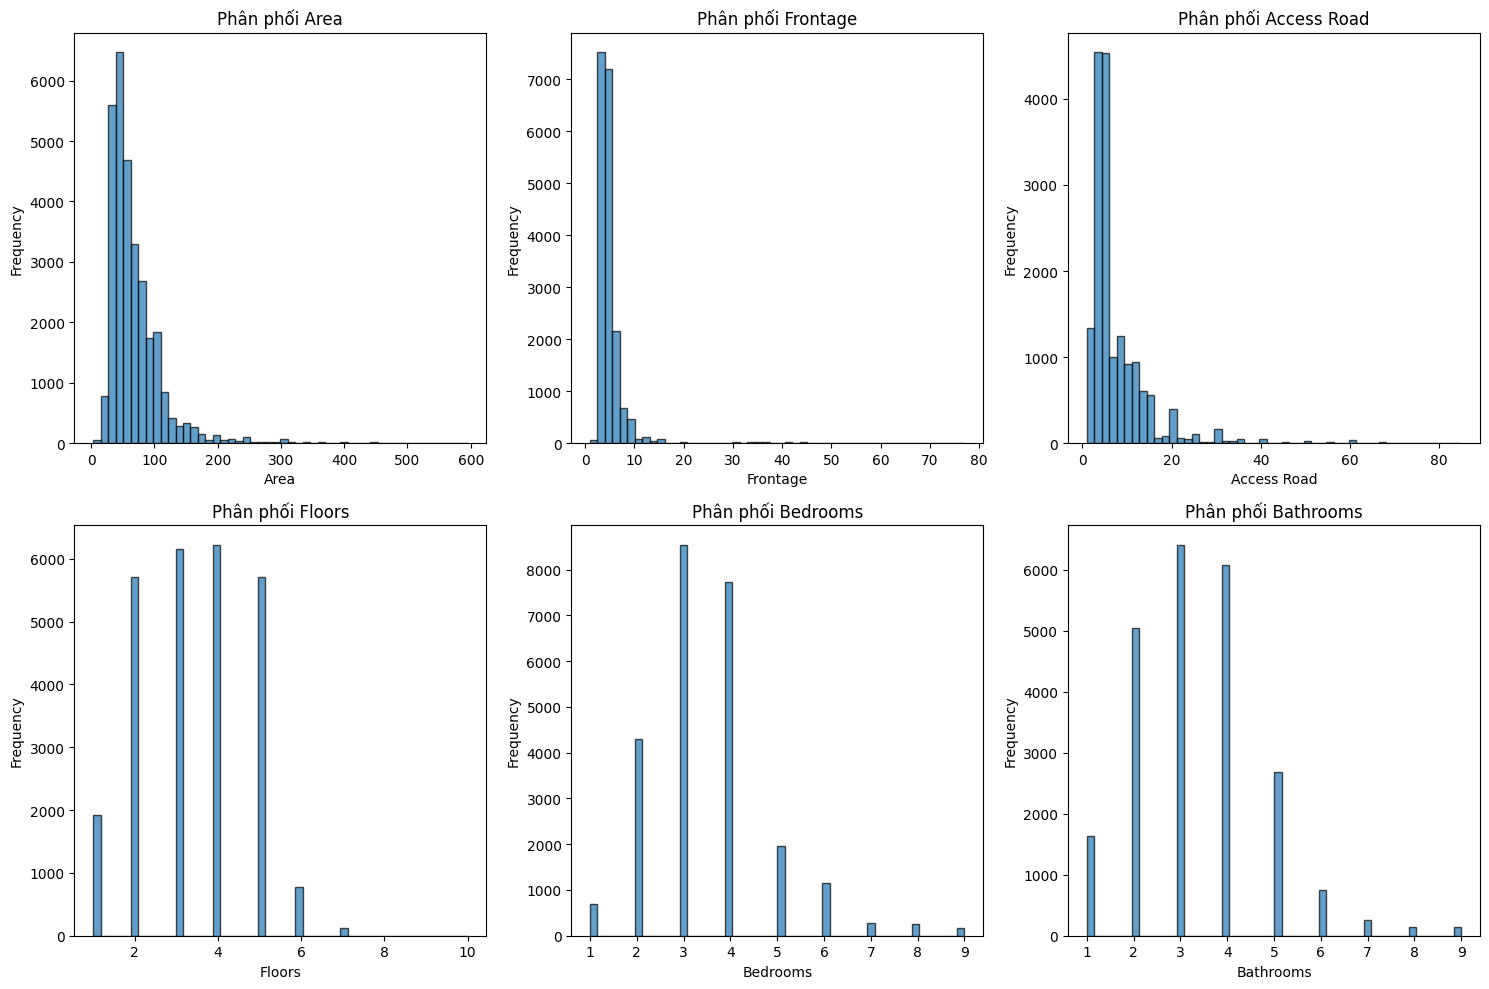


Thống kê phân phối các biến số:
               Area      Frontage   Access Road        Floors      Bedrooms  \
count  30229.000000  18665.000000  16932.000000  26626.000000  25067.000000   
mean      68.498741      5.361692      7.853800      3.410426      3.511030   
std       48.069835      4.346174      7.451313      1.328897      1.309116   
min        3.100000      1.000000      1.000000      1.000000      1.000000   
25%       40.000000      4.000000      4.000000      2.000000      3.000000   
50%       56.000000      4.500000      6.000000      3.000000      3.000000   
75%       80.000000      5.000000     10.000000      4.000000      4.000000   
max      595.000000     77.000000     85.000000     10.000000      9.000000   

          Bathrooms  
count  23155.000000  
mean       3.346837  
std        1.400181  
min        1.000000  
25%        2.000000  
50%        3.000000  
75%        4.000000  
max        9.000000  


In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

target_col = None
possible_targets = ['Price', 'price', 'gia', 'Gia', 'gia_nha', 'price_house']
for col in possible_targets:
    if col in df.columns:
        target_col = col
        break
if target_col is None:
    numeric_cols_temp = df.select_dtypes(include=[np.number]).columns
    if len(numeric_cols_temp) > 0:
        target_col = numeric_cols_temp[-1]

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
if target_col and target_col in numeric_cols:
    numeric_cols.remove(target_col)

n_cols = len(numeric_cols)
n_rows = (n_cols + 2) // 3

fig, axes = plt.subplots(n_rows, 3, figsize=(15, 5*n_rows))
axes = axes.flatten() if n_cols > 1 else [axes]

for idx, col in enumerate(numeric_cols):
    if idx < len(axes):
        axes[idx].hist(df[col].dropna(), bins=50, edgecolor='black', alpha=0.7)
        axes[idx].set_title(f'Phân phối {col}')
        axes[idx].set_xlabel(col)
        axes[idx].set_ylabel('Frequency')

for idx in range(len(numeric_cols), len(axes)):
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

print("\nThống kê phân phối các biến số:")
print(df[numeric_cols].describe())


## 2.2. Phân tích Boxplot để phát hiện outliers


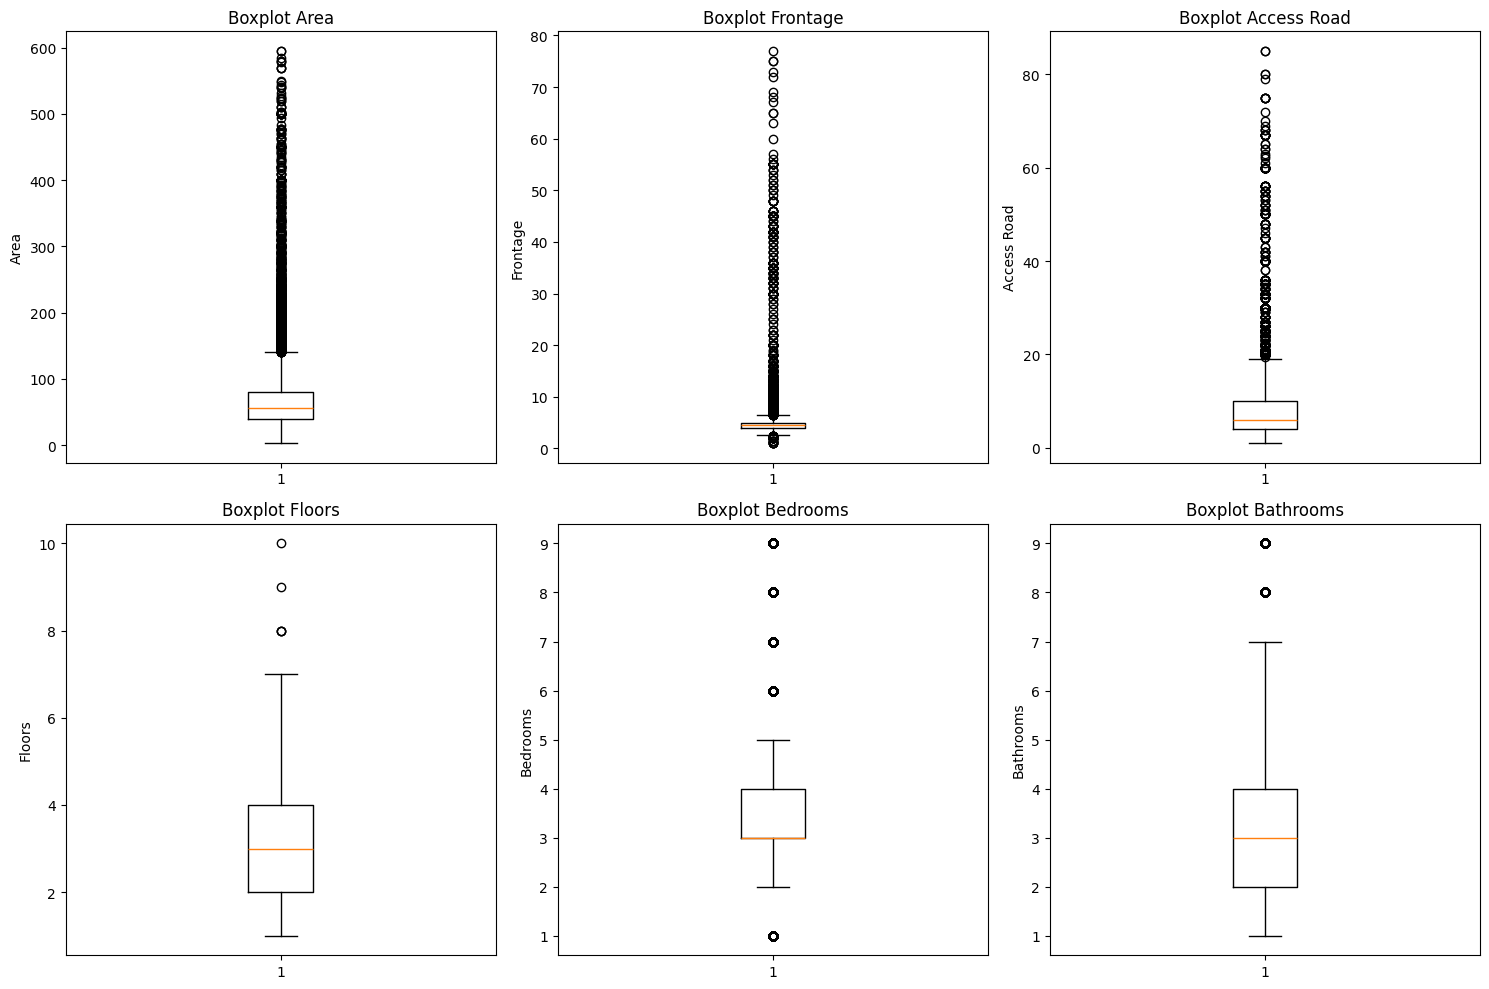


Phát hiện outliers bằng IQR method:
Area: 1636 outliers (5.41%)
Frontage: 2305 outliers (12.35%)
Access Road: 1110 outliers (6.56%)
Floors: 5 outliers (0.02%)
Bedrooms: 2532 outliers (10.10%)
Bathrooms: 287 outliers (1.24%)


In [8]:
fig, axes = plt.subplots(n_rows, 3, figsize=(15, 5*n_rows))
axes = axes.flatten() if n_cols > 1 else [axes]

for idx, col in enumerate(numeric_cols):
    if idx < len(axes):
        axes[idx].boxplot(df[col].dropna(), vert=True)
        axes[idx].set_title(f'Boxplot {col}')
        axes[idx].set_ylabel(col)

for idx in range(len(numeric_cols), len(axes)):
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

print("\nPhát hiện outliers bằng IQR method:")
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)][col]
    outlier_rate = len(outliers) / len(df[col].dropna()) * 100
    print(f"{col}: {len(outliers)} outliers ({outlier_rate:.2f}%)")


## 2.3. Phân tích Missing Values chi tiết


Tổng hợp Missing Values:
               Column  Missing_Count  Missing_Percent
5   Balcony direction          24983        82.645804
4     House direction          21239        70.260346
10    Furniture state          14119        46.706805
3         Access Road          13297        43.987562
2            Frontage          11564        38.254656
8           Bathrooms           7074        23.401370
7            Bedrooms           5162        17.076317
9        Legal status           4506        14.906216
6              Floors           3603        11.919018


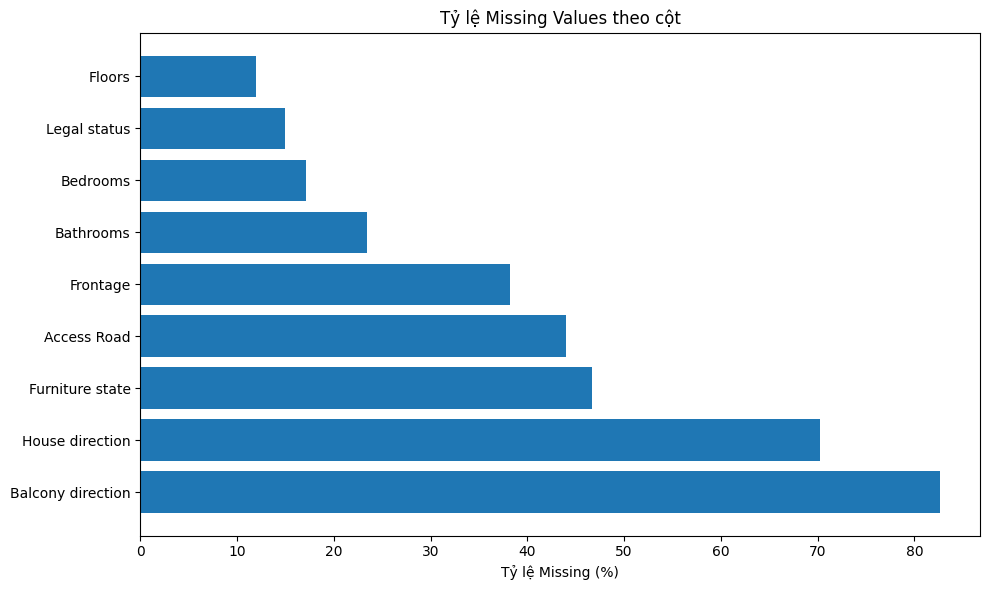

In [9]:
missing_data = df.isnull().sum()
missing_percent = (missing_data / len(df)) * 100
missing_df = pd.DataFrame({
    'Column': missing_data.index,
    'Missing_Count': missing_data.values,
    'Missing_Percent': missing_percent.values
}).sort_values('Missing_Percent', ascending=False)

print("Tổng hợp Missing Values:")
print(missing_df[missing_df['Missing_Count'] > 0])

plt.figure(figsize=(10, 6))
missing_df_filtered = missing_df[missing_df['Missing_Count'] > 0]
if len(missing_df_filtered) > 0:
    plt.barh(missing_df_filtered['Column'], missing_df_filtered['Missing_Percent'])
    plt.xlabel('Tỷ lệ Missing (%)')
    plt.title('Tỷ lệ Missing Values theo cột')
    plt.tight_layout()
    plt.show()
else:
    print("Không có missing values")


## 2.4. Phân tích tương quan giữa các biến


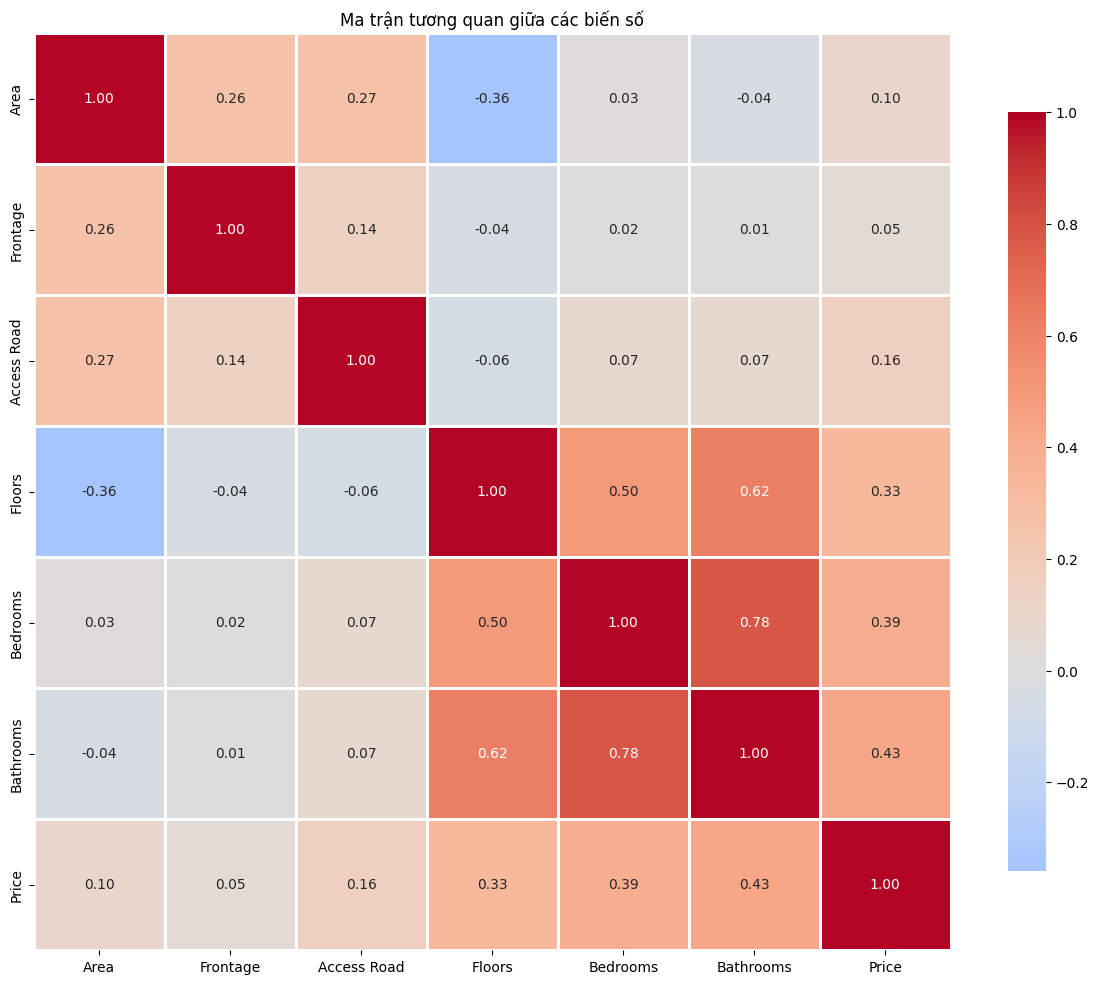


Tương quan với Price:
Price          1.000000
Bathrooms      0.434101
Bedrooms       0.389432
Floors         0.331639
Access Road    0.164280
Area           0.097593
Frontage       0.047469
Name: Price, dtype: float64


In [10]:
target_col = None
possible_targets = ['Price', 'price', 'gia', 'Gia', 'gia_nha', 'price_house']
for col in possible_targets:
    if col in df.columns:
        target_col = col
        break
if target_col is None:
    numeric_cols_temp = df.select_dtypes(include=[np.number]).columns
    if len(numeric_cols_temp) > 0:
        target_col = numeric_cols_temp[-1]

numeric_cols_for_corr = df.select_dtypes(include=[np.number]).columns.tolist()
if target_col and target_col in numeric_cols_for_corr:
    numeric_cols_for_corr.remove(target_col)

correlation_cols = numeric_cols_for_corr + [target_col] if target_col and target_col in df.columns else numeric_cols_for_corr
corr_matrix = df[correlation_cols].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Ma trận tương quan giữa các biến số')
plt.tight_layout()
plt.show()

if target_col in df.columns:
    print(f"\nTương quan với {target_col}:")
    target_corr = corr_matrix[target_col].sort_values(ascending=False)
    print(target_corr)


## 2.5. Phân tích phân phối Target Variable


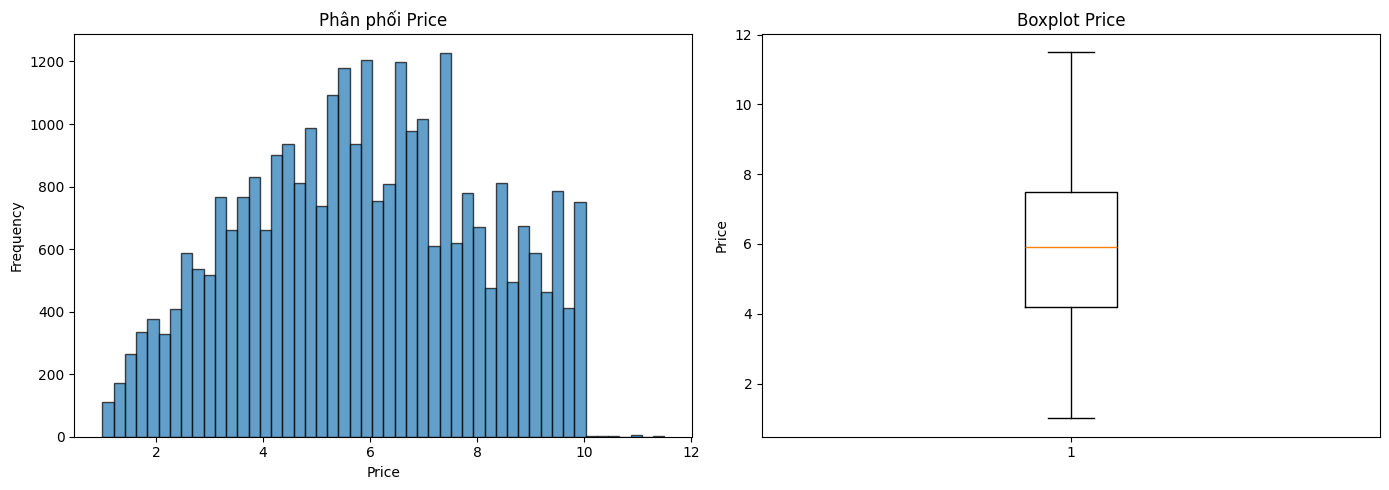


Thống kê Price:
count    30229.000000
mean         5.872078
std          2.211877
min          1.000000
25%          4.200000
50%          5.900000
75%          7.500000
max         11.500000
Name: Price, dtype: float64

Skewness: -0.0290
Kurtosis: -0.8464


In [11]:
target_col = None
possible_targets = ['Price', 'price', 'gia', 'Gia', 'gia_nha', 'price_house']
for col in possible_targets:
    if col in df.columns:
        target_col = col
        break
if target_col is None:
    numeric_cols_temp = df.select_dtypes(include=[np.number]).columns
    if len(numeric_cols_temp) > 0:
        target_col = numeric_cols_temp[-1]

if target_col and target_col in df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    axes[0].hist(df[target_col], bins=50, edgecolor='black', alpha=0.7)
    axes[0].set_title(f'Phân phối {target_col}')
    axes[0].set_xlabel(target_col)
    axes[0].set_ylabel('Frequency')
    
    axes[1].boxplot(df[target_col], vert=True)
    axes[1].set_title(f'Boxplot {target_col}')
    axes[1].set_ylabel(target_col)
    
    plt.tight_layout()
    plt.show()
    
    print(f"\nThống kê {target_col}:")
    print(df[target_col].describe())
    print(f"\nSkewness: {df[target_col].skew():.4f}")
    print(f"Kurtosis: {df[target_col].kurtosis():.4f}")


## 2.6. Phân tích các biến phân loại


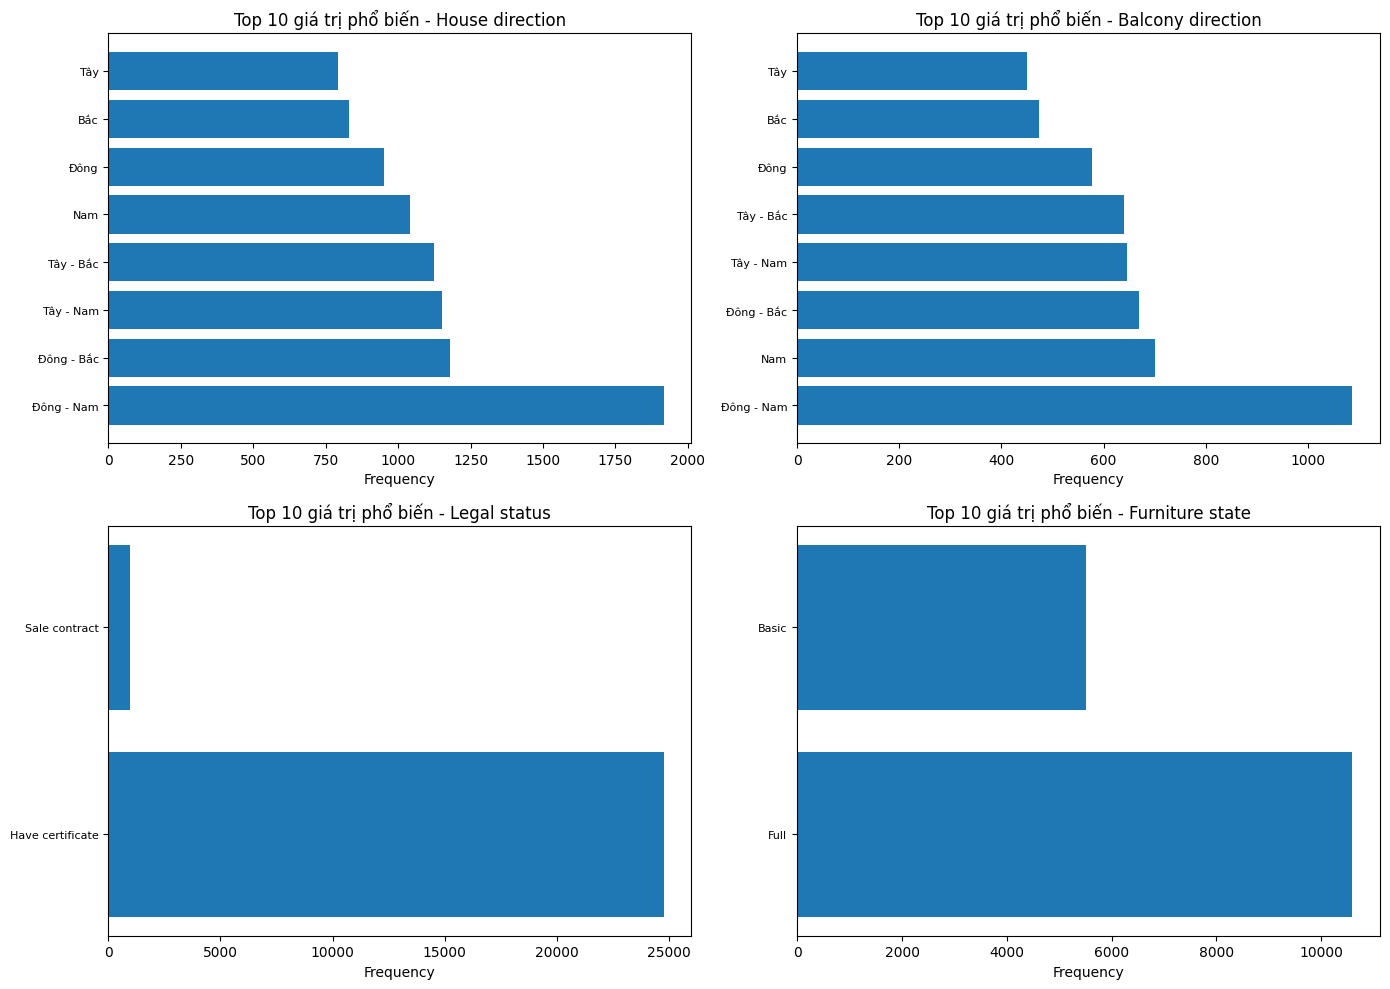


Thống kê các biến phân loại:

House direction:
  Số giá trị unique: 8
  Missing: 21239 (70.26%)
  Top 5 giá trị:
House direction
Đông - Nam    1916
Đông - Bắc    1180
Tây - Nam     1152
Tây - Bắc     1125
Nam           1042
Name: count, dtype: int64

Balcony direction:
  Số giá trị unique: 8
  Missing: 24983 (82.65%)
  Top 5 giá trị:
Balcony direction
Đông - Nam    1087
Nam            701
Đông - Bắc     670
Tây - Nam      646
Tây - Bắc      640
Name: count, dtype: int64

Legal status:
  Số giá trị unique: 2
  Missing: 4506 (14.91%)
  Top 5 giá trị:
Legal status
Have certificate    24774
Sale contract         949
Name: count, dtype: int64

Furniture state:
  Số giá trị unique: 2
  Missing: 14119 (46.71%)
  Top 5 giá trị:
Furniture state
Full     10591
Basic     5519
Name: count, dtype: int64


In [12]:
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
if 'Address' in categorical_cols:
    categorical_cols.remove('Address')

n_cat = len(categorical_cols)
if n_cat > 0:
    n_rows_cat = (n_cat + 1) // 2
    fig, axes = plt.subplots(n_rows_cat, 2, figsize=(14, 5*n_rows_cat))
    axes = axes.flatten() if n_cat > 1 else [axes]
    
    for idx, col in enumerate(categorical_cols):
        if idx < len(axes):
            value_counts = df[col].value_counts().head(10)
            axes[idx].barh(range(len(value_counts)), value_counts.values)
            axes[idx].set_yticks(range(len(value_counts)))
            axes[idx].set_yticklabels(value_counts.index, fontsize=8)
            axes[idx].set_title(f'Top 10 giá trị phổ biến - {col}')
            axes[idx].set_xlabel('Frequency')
    
    for idx in range(len(categorical_cols), len(axes)):
        axes[idx].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    print("\nThống kê các biến phân loại:")
    for col in categorical_cols:
        print(f"\n{col}:")
        print(f"  Số giá trị unique: {df[col].nunique()}")
        print(f"  Missing: {df[col].isnull().sum()} ({df[col].isnull().sum()/len(df)*100:.2f}%)")
        print(f"  Top 5 giá trị:")
        print(df[col].value_counts().head(5))
else:
    print("Không có biến phân loại để phân tích")


## 2.7. Phân tích mối quan hệ giữa Target và các biến quan trọng


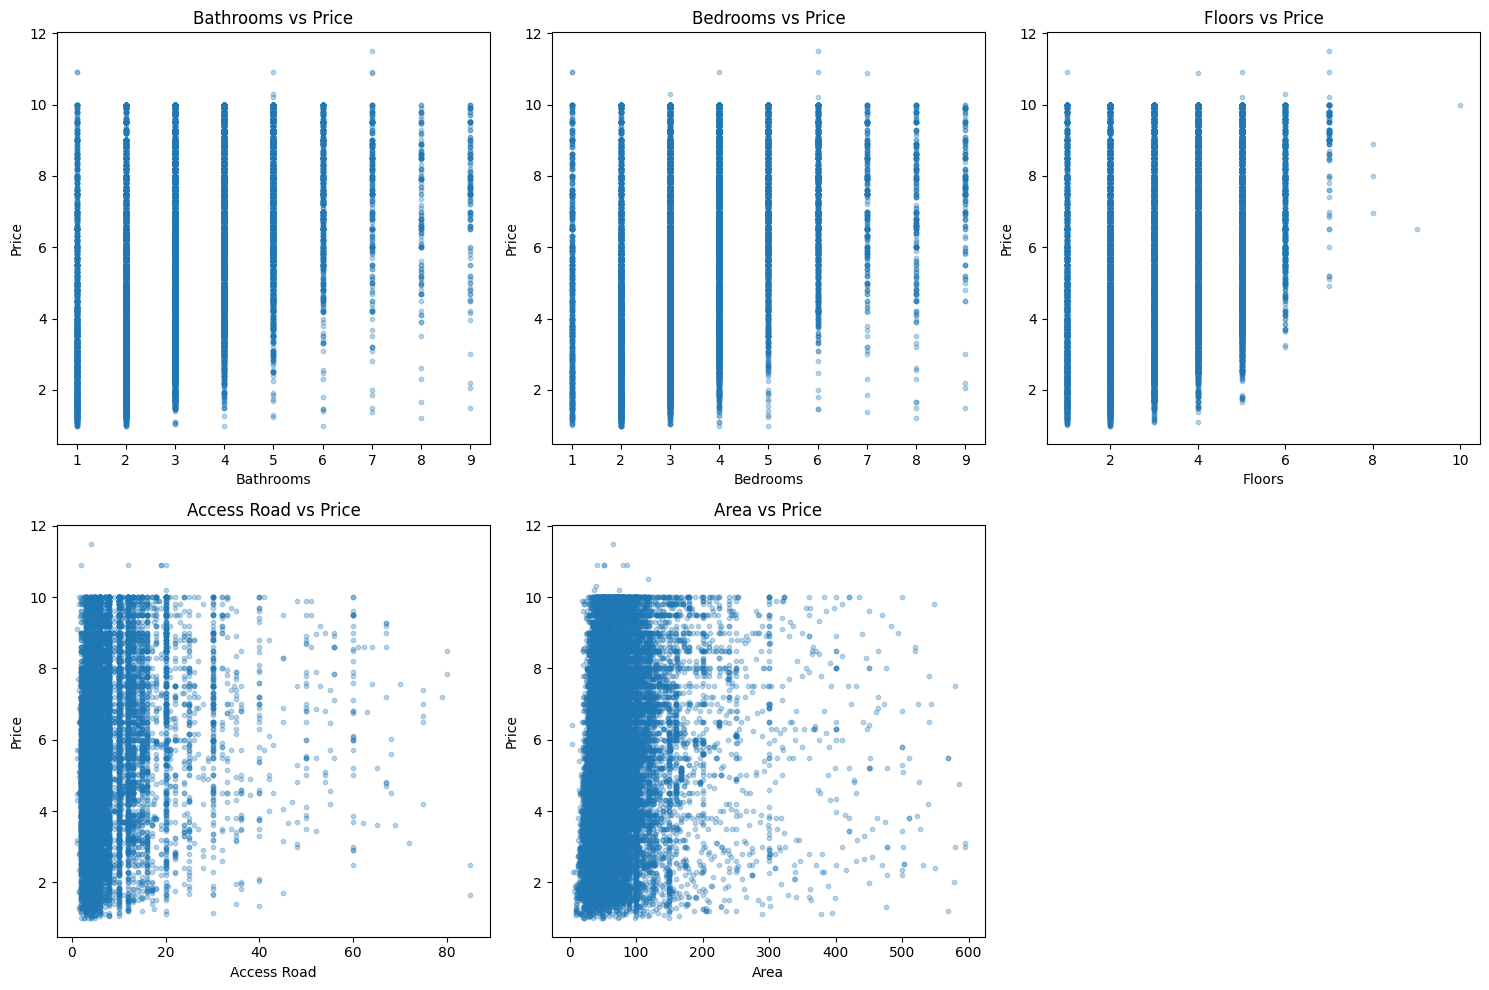


Top 5 biến có tương quan cao nhất với Price:
  Bathrooms: 0.4341
  Bedrooms: 0.3894
  Floors: 0.3316
  Access Road: 0.1643
  Area: 0.0976


In [13]:
target_col = None
possible_targets = ['Price', 'price', 'gia', 'Gia', 'gia_nha', 'price_house']
for col in possible_targets:
    if col in df.columns:
        target_col = col
        break
if target_col is None:
    numeric_cols_temp = df.select_dtypes(include=[np.number]).columns
    if len(numeric_cols_temp) > 0:
        target_col = numeric_cols_temp[-1]

numeric_cols_for_scatter = df.select_dtypes(include=[np.number]).columns.tolist()
if target_col and target_col in numeric_cols_for_scatter:
    numeric_cols_for_scatter.remove(target_col)

if target_col and target_col in df.columns and len(numeric_cols_for_scatter) > 0:
    top_corr_cols = corr_matrix[target_col].abs().sort_values(ascending=False).head(6)
    top_corr_cols = [col for col in top_corr_cols.index if col != target_col and col in numeric_cols_for_scatter][:5]
    
    if len(top_corr_cols) > 0:
        n_plots = len(top_corr_cols)
        n_rows_scatter = (n_plots + 2) // 3
        fig, axes = plt.subplots(n_rows_scatter, 3, figsize=(15, 5*n_rows_scatter))
        axes = axes.flatten() if n_plots > 1 else [axes]
        
        for idx, col in enumerate(top_corr_cols):
            if idx < len(axes):
                axes[idx].scatter(df[col], df[target_col], alpha=0.3, s=10)
                axes[idx].set_xlabel(col)
                axes[idx].set_ylabel(target_col)
                axes[idx].set_title(f'{col} vs {target_col}')
        
        for idx in range(len(top_corr_cols), len(axes)):
            axes[idx].axis('off')
        
        plt.tight_layout()
        plt.show()
        
        print(f"\nTop {len(top_corr_cols)} biến có tương quan cao nhất với {target_col}:")
        for col in top_corr_cols:
            corr_val = corr_matrix.loc[col, target_col]
            print(f"  {col}: {corr_val:.4f}")


## 3. Tiền xử lý dữ liệu

Xử lý missing values, outliers, encoding và scaling cho dataset.



In [5]:
target_col = None
possible_targets = ['Price', 'price', 'gia', 'Gia', 'gia_nha', 'price_house']

for col in possible_targets:
    if col in df.columns:
        target_col = col
        break

if target_col is None:
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    if len(numeric_cols) > 0:
        target_col = numeric_cols[-1]
        print(f"Không tìm thấy cột target, sử dụng cột số cuối cùng: {target_col}")
    else:
        raise ValueError("Không tìm thấy cột target phù hợp")

print(f"Cột target: {target_col}")

df_processed = df.copy()

if 'Address' in df_processed.columns:
    address_unique = df_processed['Address'].nunique()
    print(f"\nAddress có {address_unique} giá trị unique")
    if address_unique > len(df_processed) * 0.5:
        print("Loại bỏ cột Address vì quá nhiều giá trị unique (sẽ tạo quá nhiều features)")
        df_processed = df_processed.drop(columns=['Address'])

print(f"\nKích thước sau khi xử lý Address: {df_processed.shape}")

preprocessor = DataPreprocessor(
    missing_strategy='median',
    outlier_method='iqr',
    encoding_method='onehot',
    scaling_method='standard'
)

X_train, X_test, y_train, y_test, feature_names = preprocessor.preprocess(
    df_processed, target_col, test_size=0.2, random_state=42
)

print(f"\nKích thước train: {X_train.shape}")
print(f"Kích thước test: {X_test.shape}")
print(f"Số features: {len(feature_names)}")



Cột target: Price

Address có 10265 giá trị unique

Kích thước sau khi xử lý Address: (30229, 12)


D:\ML_house_price\src\preprocess\preprocess.py:29: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)
D:\ML_house_price\src\preprocess\preprocess.py:29: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(v


Kích thước train: (12597, 6106)
Kích thước test: (3150, 6106)
Số features: 6106


## 4. Huấn luyện model XGBoost



In [6]:
model, best_params, best_score = train_xgboost(
    X_train, y_train, use_grid_search=False, n_iter=30, cv=5
)

print(f"Best parameters: {best_params}")
print(f"Best CV score (neg MSE): {best_score}")

metadata = {
    'best_params': best_params,
    'best_cv_score': float(best_score),
    'n_features': len(feature_names),
    'n_train_samples': len(X_train),
    'n_test_samples': len(X_test)
}

model_path, preprocessor_path, metadata_path = save_model(
    model, preprocessor, metadata
)

print(f"\nĐã lưu model tại: {model_path}")
print(f"Đã lưu preprocessor tại: {preprocessor_path}")
print(f"Đã lưu metadata tại: {metadata_path}")



D:\ML_house_price\venv\Lib\site-packages\xgboost\training.py:199: UserWarning: [02:06:17] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\context.cc:53: No visible GPU is found, setting device to CPU.
  bst.update(dtrain, iteration=i, fobj=obj)
D:\ML_house_price\venv\Lib\site-packages\xgboost\training.py:199: UserWarning: [02:06:17] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\context.cc:207: Device is changed from GPU to CPU as we couldn't find any available GPU on the system.
  bst.update(dtrain, iteration=i, fobj=obj)


GPU có sẵn nhưng XGBoost chưa được build với GPU support.
Để dùng GPU, cần cài CUDA và build XGBoost từ source hoặc dùng conda.
Sử dụng CPU để train (n_jobs=-1 để dùng tất cả cores)
Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best parameters: {'subsample': 1.0, 'n_estimators': 300, 'max_depth': 7, 'learning_rate': 0.2, 'colsample_bytree': 0.9}
Best CV score (neg MSE): -2.6193498437762885

Đã lưu model tại: src\models\xgboost_model_20251224_022918.pkl
Đã lưu preprocessor tại: src\models\preprocessor_20251224_022918.pkl
Đã lưu metadata tại: src\models\metadata_20251224_022918.json


## 5. Đánh giá model



In [7]:
y_pred = model.predict(X_test)

metrics = calculate_regression_metrics(y_test, y_pred)
print("Kết quả đánh giá:")
for metric, value in metrics.items():
    print(f"{metric}: {value:.4f}")

plot_predictions(y_test, y_pred, title='Predictions vs Actual')
plot_residuals(y_test, y_pred)

if hasattr(model, 'feature_importances_'):
    plot_feature_importance(model, feature_names, top_n=20)

save_evaluation_report(metrics)



Kết quả đánh giá:
RMSE: 1.6437
MAE: 1.2961
MAPE: 28.9818
R2: 0.3855


## 6. Lưu dữ liệu đã xử lý



In [8]:
processed_dir = project_root / 'data' / 'processed'
processed_dir.mkdir(parents=True, exist_ok=True)

train_df = pd.DataFrame(X_train, columns=feature_names)
train_df[target_col] = y_train.values
train_df.to_csv(processed_dir / 'train.csv', index=False)

test_df = pd.DataFrame(X_test, columns=feature_names)
test_df[target_col] = y_test.values
test_df.to_csv(processed_dir / 'test.csv', index=False)

print("Đã lưu dữ liệu đã xử lý vào data/processed/")



Đã lưu dữ liệu đã xử lý vào data/processed/
